# BioJEPA v1.0 Training Pipeline - Local Composer Training

This notebook trains the composer portion of the notebook locally on an M4 Macbook.  We found that because of how this model trains, it runs faster locally and, because of this, we did our HPO locally.  We train the composer first locally, then pick up the rest of the BioJEPA-AC on a server.  

In [4]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v1_0 import BioJepa, BioJepaConfig
from dataloader_v1_0 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v1_0 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v1_0 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

In [5]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/jepa/v1_0').expanduser()
ref_root = Path('~/data/jepa/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cpu


## Hyperparameters

In [6]:
# Model architecture -- Trial 39 winning recipe (75/25 T22/T23 interpolation), composite 0.8853 at ep4
# Predictor dims decoupled from encoder: predictor HPO v1 winner (128/4/4, ~32.6% of encoder).
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=5.699,
    film_linear_multiple=0.6769,
    sim_coeff=50.18,
    std_coeff=25.44,            # sim_coeff * std_to_sim_ratio (0.5069)
    cov_coeff=0.5158,           # sim_coeff * cov_to_sim_ratio (0.01028)
    pert_latent_dim=128,
    pert_mode_dim=64,
    predictor_embed_dim=128,
    predictor_n_layer=4,
    predictor_heads=4,
)

# Encoder short: 10 epochs. Rampup matches HPO absolute timing (HPO used 50-ep schedule with
# warmup_pct=0.05 -> 2.5 ep absolute warmup). Setting warmup_pct=0.25 here reproduces the same
# 2.5 ep absolute warmup over the 10-ep horizon. context_coeff=0.0 matches HPO (ramp never fired
# in 4-ep trials). phase2_start_pct=0.8 adds production-style decay over the last 2 epochs.
encoder_cfg = EncoderTrainingConfig(
    epochs=10, lr=6.126e-5, batch_size=64,
    warmup_pct=0.25, weight_decay=0.05, phase2_start_pct=0.8,
    context_coeff=0.0, ema_final_momentum=None,
)

# Composer: v11 alignment HPO winner (trial #42, composite 0.6949 at 10k-epoch horizon)
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=2.147e-4, batch_size=64, weight_decay=2.512e-3, temperature=7.559e-4, chemical_fraction=0.1,
)

# AC short: 5 epochs. Predictor HPO v1 winner (128/4/4, middle-of-plateau).
# lr 4e-3 tuned at batch 64; beta_nll_target 0.95 (plateau 0.9-1.0); mask anneal over last 2 ep.
ac_cfg = ACTrainingConfig(
    epochs=5, predictor_lr=4e-3, batch_size=64, beta_nll_target=0.95,
    mask_anneal_pct=0.4, mask_anneal_floor=0.0, composer_lr_mult=0.01,
)

# Decoder short: 5 epochs. Linear head converges in 3-5 epochs.
decoder_cfg = DecoderConfig(epochs=5, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [7]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,522
ACpredictor: 2,565,760
PerturbationComposer: 444,224


## Stage 0: Composer Training

In [8]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device,
    seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
  modality balancing: target chemical_fraction=10%
  adjusted total_samples=11829 (from 1 shards)
found 1 shards for split val


In [9]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, 
                                      target_bank, composer_cfg, device, data_cfg.checkpoint_dir, 
                                      use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Composer training: 11829 samples, 184 steps/epoch, 1840000 total steps
InfoNCE loss (temperature: 0.0007559)
Step 0 | Loss: 75.15177 | LR: 8.59e-06
Step 2500 | Loss: 6.17851 | LR: 8.96e-06
Step 5000 | Loss: 4.71687 | LR: 1.01e-05
Step 7500 | Loss: 3.64155 | LR: 1.20e-05
Step 10000 | val loss: 4.1363
Step 10000 | Loss: 3.36555 | LR: 1.45e-05
Step 12500 | Loss: 3.70945 | LR: 1.78e-05
Step 15000 | Loss: 3.26303 | LR: 2.18e-05
Step 17500 | Loss: 3.46900 | LR: 2.65e-05
Step 20000 | val loss: 4.5390
Step 20000 | Loss: 3.64332 | LR: 3.17e-05
Step 22500 | Loss: 3.28413 | LR: 3.75e-05
Step 25000 | Loss: 3.40105 | LR: 4.39e-05
Step 27500 | Loss: 3.40500 | LR: 5.08e-05
Step 30000 | val loss: 4.4103
Step 30000 | Loss: 3.50882 | LR: 5.81e-05
Step 32500 | Loss: 3.57491 | LR: 6.58e-05
Step 35000 | Loss: 3.37495 | LR: 7.38e-05
Step 37500 | Loss: 3.22484 | LR: 8.22e-05
Step 40000 | val loss: 4.2834
Step 40000 | Loss: 3.04136 | LR: 9.07e-05
Step 42500 | Loss: 2.77821 | LR: 9.94e-05
Step 45000 | Loss: 3.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


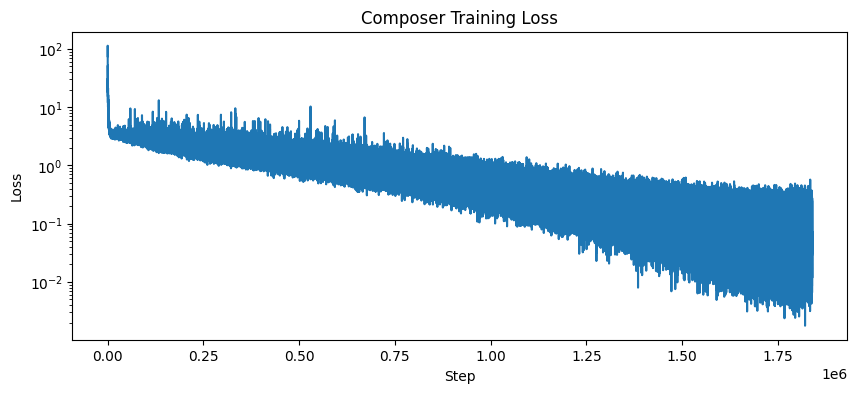

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()